# Imports 

In [1]:
import pandas as pd
from collections import defaultdict
import sys
import os
import shutil as sh
import urllib
import tarfile
import numpy as np
import math
import seaborn as sns
import glob, os
import importlib
import gzip
import MDAnalysis as mda
import nglview as nv
import requests
import json
from biopandas.pdb import PandasPdb
from Bio import AlignIO
import re
from io import StringIO

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import ConvexHull

from urllib.error import HTTPError
from pathlib import Path
from ipywidgets import interact, interactive, fixed, interact_manual, IntProgress
import ipywidgets as widgets # type: ignore
from IPython.display import display, Markdown, clear_output

# Methods

In [23]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.feature_selection import r_regression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder



def load_data(path):
    """
    Load data from the path were it was stored.
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"The file at {path} was not found.")
    return pd.read_csv(path)

def preprocess_data(df, columns_to_drop=[], categorical_cols=[]):
    """
    Drop uneccessary columns, 
    Encode categorical features, 
    Handle missing values
    """
    encodings: dict[str, np.ndarray] = {}

    # Drop unwanted columns
    if columns_to_drop:
        drop_list = [c for c in columns_to_drop if c in df.columns]
        df = df.drop(columns=drop_list)

    # Label‐encode only the columns listed in categorical_cols
    if categorical_cols:
        for col in categorical_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                encodings[col] = le.classes_.copy()
                

    # Identify numeric columns and build the pipeline
    num_list = df.select_dtypes(include=[np.number]).columns.tolist()

    num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='mean'))])
    df[num_list] = num_pipeline.fit_transform(df[num_list])

    return df, encodings

def preprocess_data(
    df: pd.DataFrame,
    y: pd.Series = None,
    columns_to_drop: list[str]    = None,
    categorical_cols: list[str]   = None,
    encoding: str                 = 'label'
) -> tuple[pd.DataFrame, dict]:
    """
    1) Drop columns in `columns_to_drop`.
    2) Encode the columns in `categorical_cols` using the chosen strategy:
         - 'label'  : sklearn LabelEncoder per-column (maps to 0..n-1)
         - 'onehot' : sklearn OneHotEncoder (expands to dummies; drop='first' to avoid collinearity)
         - 'target' : category_encoders.TargetEncoder (requires y, mean-target encode)
    3) Impute missing values in all numeric columns (mean).
    
    Returns:
      - df_transformed: DataFrame after drop, encode, impute
      - encoders:      dict of fitted encoders (or encoder.attrs if multi-col)
    """
    df = df.copy()
    encoders = {}

    # 1) Drop
    if columns_to_drop:
        to_drop = [c for c in columns_to_drop if c in df.columns]
        df.drop(columns=to_drop, inplace=True)

    # 2) Encode
    if categorical_cols:
        missing = [c for c in categorical_cols if c not in df.columns]
        if missing:
            raise ValueError(f"categorical_cols not in df: {missing}")
        
        if encoding == 'label':
            # one LabelEncoder per column
            for col in categorical_cols:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                encoders[col] = le  # you can inspect le.classes_
        
        elif encoding == 'onehot':
        # ColumnTransformer to one-hot the listed columns, drop remainder
            ohe = OneHotEncoder(
                 handle_unknown='ignore',
                drop='first',
                sparse_output=False   # use this instead of sparse=False
            )
            ct = ColumnTransformer(
                 [('ohe', ohe, categorical_cols)],
                remainder='drop'
            )
            arr = ct.fit_transform(df)
            cols = ct.get_feature_names_out()
            df = pd.DataFrame(arr, columns=cols, index=df.index)
            encoders['onehot'] = ct

    # 3) Impute numeric
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if num_cols:
        num_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='mean'))
        ])
        df[num_cols] = num_pipe.fit_transform(df[num_cols])
        encoders['imputer'] = num_pipe.named_steps['imputer']

    return df, encoders

def separate_features_target(df, target, columns_to_remove=None):
    if columns_to_remove is None:
        columns_to_remove=[]
    columns_to_remove=set(columns_to_remove + [target])
    X=df.drop(columns=[col for col in columns_to_remove if col in df.columns])
    y=df[target]
    return X, y


def select_features(X, y, threshold=0.1):
    correlations = pd.Series(r_regression(X, y), index=X.columns)
    selected_features = correlations[correlations.abs() >= threshold].index.tolist()
    print(f"The selected features of {X.shape[1]} were: {len(selected_features)}")
    return selected_features, correlations

## Download complete dataset with all anotation at residue-level

In [4]:
import zipfile
import os

zip_path = "/home/user_stel/AISB/Project/Ressources/datasets/S2 File.csv.zip"
# Remove the “.zip” to get the output directory name
extract_dir = zip_path[:-4]

# Make sure the target folder exists (or create it)
os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
except zipfile.BadZipFile:
    print("⚠️ Warning: BadZipFile raised – the .zip may be corrupted.")
except Exception as e:
    print(f"⚠️ Warning: {e}")

print("✅ Extracted all files into:", extract_dir)


✅ Extracted all files into: /home/user_stel/AISB/Project/Ressources/datasets/S2 File.csv


In [3]:
path_to_data = "/home/user_stel/AISB/Project/Ressources/datasets/S2 File.csv/S2 File.csv"

df = load_data(path_to_data)

print(df)

       domain  cathpdb   pdb uniprot_acc  uniprot_id residue_name    IBS  \
0          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
1          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
2          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
3          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
4          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
...       ...      ...   ...         ...         ...          ...    ...   
183885    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183886    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183887    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183888    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183889    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS   True   

       chain_id  residue_number  b_factor  ...  S35    S60      S95  \
0             A 

In [ ]:
# get column names 
print("Column names:")
for col in df.columns:
    print(col)

Column names:
domain
cathpdb
pdb
uniprot_acc
uniprot_id
residue_name
IBS
chain_id
residue_number
b_factor
sec_struc
sec_struc_full
prot_block
data_type
Experimental Method
resolution
RSA_total_freesasa_tien
convhull_vertex
protrusion
is_hydrophobic_protrusion
is_co_insertable
neighboursList
density
exposed
S35
S60
S95
S100
uniref50
uniref90
uniref100
origin
location
taxon


In [ ]:
# get unique domain entries 
unique_domains = df["domain"].unique()
print(unique_domains)

['PH' 'C2' 'START' 'C1' 'C2DIS' 'PX' 'PLD' 'ANNEXIN' 'PLA']


## Data Preprocessing 

In [4]:
# Temporary fix: redefine type to have HIS as polar.
AATYPE = {
    "LEU": "Hydrophobic,H-non-aromatic",
    "ILE": "Hydrophobic,H-non-aromatic",
    "CYS": "Hydrophobic,H-non-aromatic",
    "MET": "Hydrophobic,H-non-aromatic",
    "TYR": "Hydrophobic,H-aromatic",
    "TRP": "Hydrophobic,H-aromatic",
    "PHE": "Hydrophobic,H-aromatic",
    "HIS": "Polar",
    "LYS": "Positive",
    "ARG": "Positive",
    "ASP": "Negative",
    "GLU": "Negative",
    "VAL": "Non-polar",
    "ALA": "Non-polar",
    "SER": "Polar",
    "ASN": "Polar",
    "GLY": "Non-polar",
    "PRO": "Non-polar",
    "GLN": "Polar",
    "THR": "Polar",
    "UNK": "none"
}
df["type"] = df.residue_name.apply(lambda x: AATYPE[x])
print(df)

       domain  cathpdb   pdb uniprot_acc  uniprot_id residue_name    IBS  \
0          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
1          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
2          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
3          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
4          PH  2m14A00  2M14      P32776  TFB1_YEAST          ASN  False   
...       ...      ...   ...         ...         ...          ...    ...   
183885    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183886    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183887    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183888    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS  False   
183889    PLA  5p2pA00  5P2P      P00592   PA21B_PIG          CYS   True   

       chain_id  residue_number  b_factor  ...    S60      S95       S100  \
0         

1. **Target column:   IBS**<br>
    false(non-IBS)             → 0<br>
    true(IBS)                  → 1<br>
2. Feature column:  **convhull_vertex**<br>
    false                      → 0<br>
    true                       → 1<br>
3. Feature column:  **protrusion**<br>
    false                      → 0<br>
    true                       → 1<br>
4. Feature column:  **is_hydrophobic_protrusion**<br>
    false                      → 0<br>
    true                       → 1<br>
5. Feature column:  **is_co_insertable** <br>
    false                      → 0<br>
    true                       → 1<br>
6. Feature column:  **exposed**<br>
    false                      → 0<br>
    true                       → 1<br>
7. Feature column:  **type**<br>
    Hydrophobic,H-aromatic     → 0<br>
    Hydrophobic,H-non-aromatic → 1<br>
    Negative                   → 2<br>
    Non-polar                  → 3<br>
    Polar                      → 4<br>
    Positive                   → 5<br>
8. Feature column:  **residue_name**<br>
    0 → ALA<br>
    1 → ARG<br>
    2 → ASN<br>
    3 → ASP<br>
    4 → CYS<br>
    5 → GLN<br>
    6 → GLU<br>
    7 → GLY<br>
    8 → HIS<br>
    9 → ILE<br>
    10 → LEU<br>
    11 → LYS<br>
    12 → MET<br>
    13 → PHE<br>
    14 → PRO<br>
    15 → SER<br>
    16 → THR<br>
    17 → TRP<br>
    18 → TYR<br>
    19 → VAL<br>


In [21]:
cols_to_drop = ["cathpdb", "pdb", "chain_id", "uniprot_acc", "uniprot_id", "b_factor", "sec_struc", "sec_struc_full", "prot_block", "data_type", 
                "Experimental Method", "resolution", "RSA_total_freesasa_tien", "neighboursList", "density", "S35", "S60", "S95",
                "S100", "uniref50", "uniref90", "uniref100", "origin", "location", "taxon"]
categorical_cols = ["IBS", "residue_name", "convhull_vertex", "protrusion", "is_hydrophobic_protrusion", "is_co_insertable", "exposed", "type"]
df_enc, encs = preprocess_data(
    df,
    columns_to_drop=cols_to_drop,
    categorical_cols=categorical_cols,
    encoding='label'
)
# inspect mappings:
print(encs['convhull_vertex'].classes_)
print(df_enc)


['False' 'True']
       domain  residue_name  IBS  residue_number  convhull_vertex  protrusion  \
0          PH           2.0  0.0            19.0              0.0         0.0   
1          PH           2.0  0.0            75.0              1.0         1.0   
2          PH           2.0  0.0            78.0              1.0         1.0   
3          PH           2.0  0.0            92.0              1.0         0.0   
4          PH           2.0  0.0            93.0              1.0         1.0   
...       ...           ...  ...             ...              ...         ...   
183885    PLA           4.0  0.0            91.0              0.0         0.0   
183886    PLA           4.0  0.0            96.0              0.0         0.0   
183887    PLA           4.0  0.0            98.0              0.0         0.0   
183888    PLA           4.0  0.0           105.0              0.0         0.0   
183889    PLA           4.0  1.0           124.0              0.0         0.0   

        is

In [27]:
# for trees 
y = df['IBS'].astype(int)
df_te, encs = preprocess_data(
    df,
    y=y,
    columns_to_drop=cols_to_drop,
    categorical_cols=categorical_cols,
    encoding='target'
)
print(df_te)


       domain residue_name    IBS  residue_number  convhull_vertex  \
0          PH          ASN  False            19.0            False   
1          PH          ASN  False            75.0             True   
2          PH          ASN  False            78.0             True   
3          PH          ASN  False            92.0             True   
4          PH          ASN  False            93.0             True   
...       ...          ...    ...             ...              ...   
183885    PLA          CYS  False            91.0            False   
183886    PLA          CYS  False            96.0            False   
183887    PLA          CYS  False            98.0            False   
183888    PLA          CYS  False           105.0            False   
183889    PLA          CYS   True           124.0            False   

        protrusion  is_hydrophobic_protrusion  is_co_insertable  exposed  \
0            False                      False             False     True   
1      

In [5]:
cols_to_drop = ["cathpdb", "pdb", "chain_id", "uniprot_acc", "uniprot_id", "b_factor", "sec_struc", "sec_struc_full", "prot_block", "data_type", 
                "Experimental Method", "resolution", "RSA_total_freesasa_tien", "neighboursList", "density", "S35", "S60", "S95",
                "S100", "uniref50", "uniref90", "uniref100", "origin", "location", "taxon"]
categorical_cols = ["IBS", "residue_name", "convhull_vertex", "protrusion", "is_hydrophobic_protrusion", "is_co_insertable", "exposed", "type"]
df_processed, encodings = preprocess_data(df, columns_to_drop=cols_to_drop, categorical_cols=categorical_cols)
# print(df_processed)

print("Mapping for 'residue_name':")
for code, label in enumerate(encodings["residue_name"]):
    print(f"  {code} → {label}")

Mapping for 'residue_name':
  0 → ALA
  1 → ARG
  2 → ASN
  3 → ASP
  4 → CYS
  5 → GLN
  6 → GLU
  7 → GLY
  8 → HIS
  9 → ILE
  10 → LEU
  11 → LYS
  12 → MET
  13 → PHE
  14 → PRO
  15 → SER
  16 → THR
  17 → TRP
  18 → TYR
  19 → VAL


In [11]:
print(df_processed)

       domain  residue_name  IBS  residue_number  convhull_vertex  protrusion  \
0          PH           2.0  0.0            19.0              0.0         0.0   
1          PH           2.0  0.0            75.0              1.0         1.0   
2          PH           2.0  0.0            78.0              1.0         1.0   
3          PH           2.0  0.0            92.0              1.0         0.0   
4          PH           2.0  0.0            93.0              1.0         1.0   
...       ...           ...  ...             ...              ...         ...   
183885    PLA           4.0  0.0            91.0              0.0         0.0   
183886    PLA           4.0  0.0            96.0              0.0         0.0   
183887    PLA           4.0  0.0            98.0              0.0         0.0   
183888    PLA           4.0  0.0           105.0              0.0         0.0   
183889    PLA           4.0  1.0           124.0              0.0         0.0   

        is_hydrophobic_prot

### Class imbalance & Class Separability 

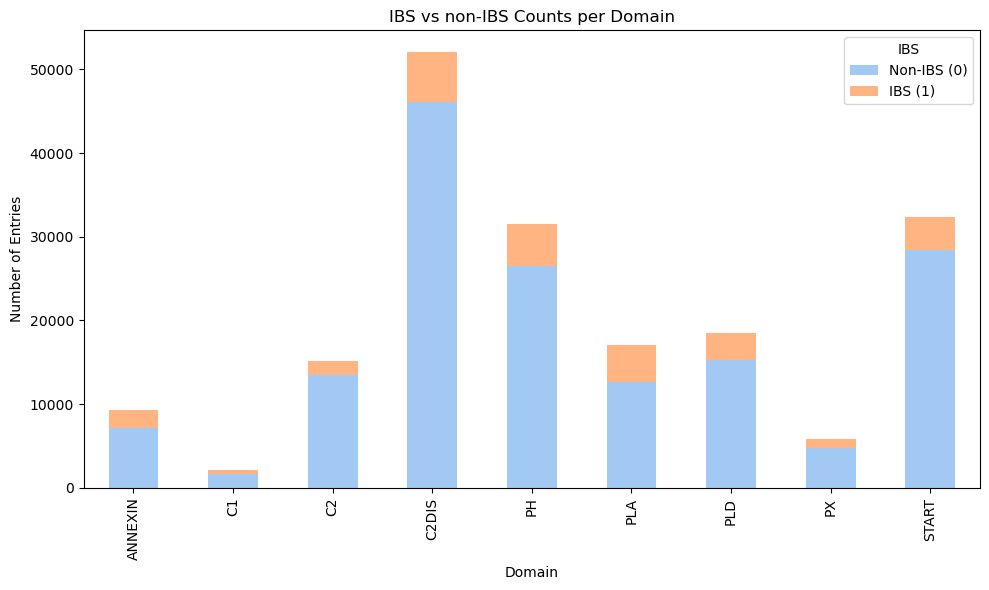

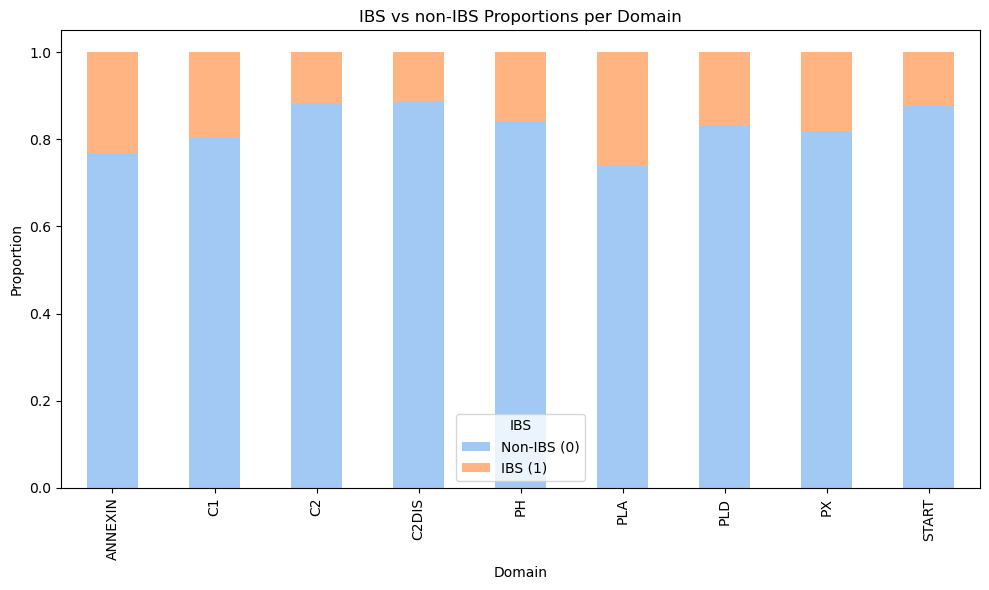

In [12]:
# this code block can be used in irder to show -for each superfamily- how much of the protein 
# is actually occupied from the interfacial binding sites in comparison to the non-IBS
# plots for each superfamily
# to visualize IBS vs non-IBS (1 vs 0) across 9 unique domains, 
# we need to group by domain and count the number of IBS (1) and non-IBS (0) entries for each

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by domain and IBS label (0/1), then count
ibs_counts = df_processed.groupby(['domain', 'IBS']).size().unstack(fill_value=0)

# Optional: Ensure all 9 domains appear in the same order (if needed)
# desired_domain_order = ["C2", "PLD", ...]  # if you have a specific order
# ibs_counts = ibs_counts.reindex(desired_domain_order)

# Bar plot (stacked)
ibs_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette("pastel", n_colors=2)
)
plt.title("IBS vs non-IBS Counts per Domain")
plt.xlabel("Domain")
plt.ylabel("Number of Entries")
plt.legend(title='IBS', labels=['Non-IBS (0)', 'IBS (1)'])
plt.tight_layout()
plt.show()

# Optional: Proportions instead of raw counts
ibs_props = ibs_counts.div(ibs_counts.sum(axis=1), axis=0)

# Stacked bar plot of proportions
ibs_props.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette("pastel", n_colors=2)
)
plt.title("IBS vs non-IBS Proportions per Domain")
plt.xlabel("Domain")
plt.ylabel("Proportion")
plt.legend(title='IBS', labels=['Non-IBS (0)', 'IBS (1)'])
plt.tight_layout()
plt.show()


In [7]:
# Count how many residues are labeled as “IBS” vs “non‐IBS”:
df["IBS"].value_counts()

# How many hydrophobic protrusions reside in IBS vs non‐IBS?
df[df["is_hydrophobic_protrusion"] & (df["IBS"] == 1)].shape[0]


IBS
False    156007
True      27883
Name: count, dtype: int64

1454

## Feature Assessment & Selection

Highly correlated pairs:
convhull_vertex  protrusion    0.836999
dtype: float64
Species to remove: {'protrusion'}
Reduced from 10 to 9 columns.


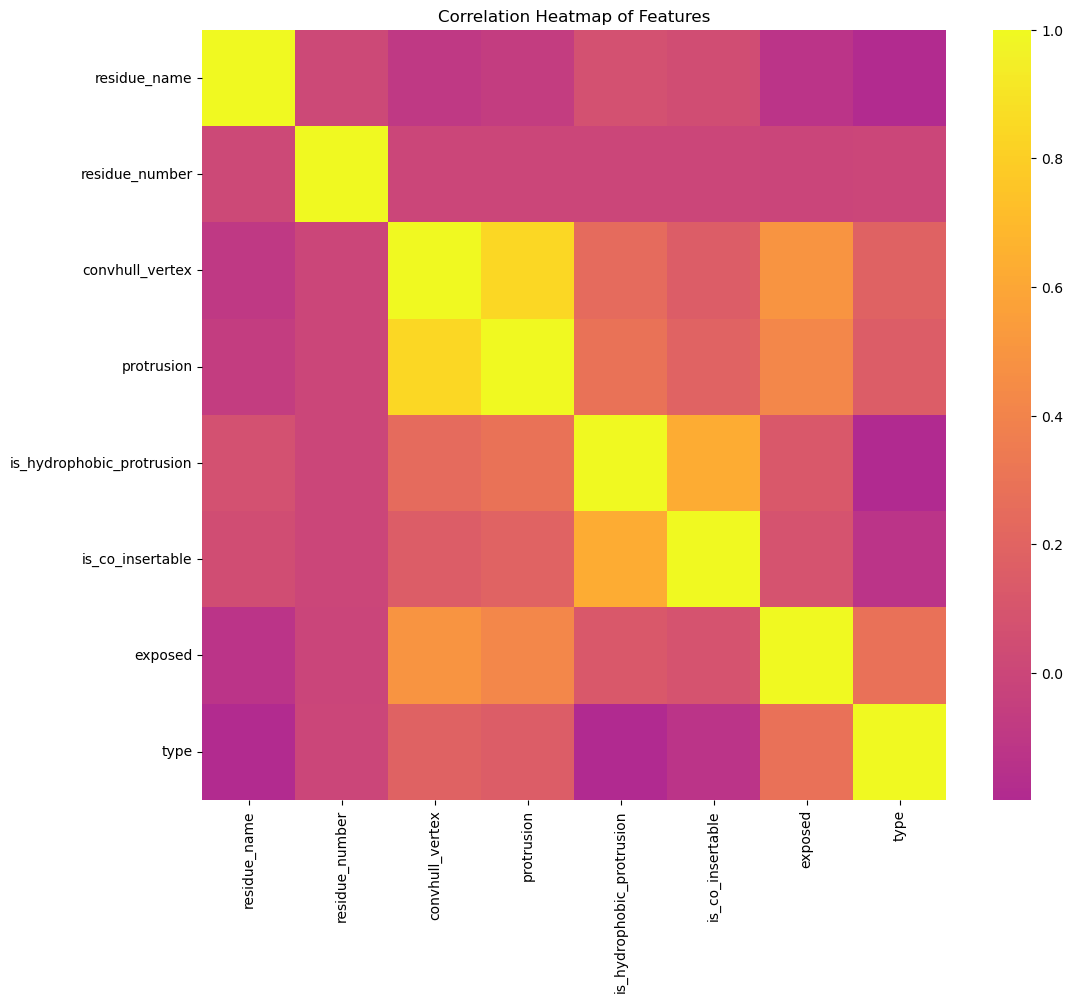

       domain  residue_name  IBS  residue_number  convhull_vertex  \
0          PH           2.0  0.0            19.0              0.0   
1          PH           2.0  0.0            75.0              1.0   
2          PH           2.0  0.0            78.0              1.0   
3          PH           2.0  0.0            92.0              1.0   
4          PH           2.0  0.0            93.0              1.0   
...       ...           ...  ...             ...              ...   
183885    PLA           4.0  0.0            91.0              0.0   
183886    PLA           4.0  0.0            96.0              0.0   
183887    PLA           4.0  0.0            98.0              0.0   
183888    PLA           4.0  0.0           105.0              0.0   
183889    PLA           4.0  1.0           124.0              0.0   

        is_hydrophobic_protrusion  is_co_insertable  exposed  type  
0                             0.0               0.0      1.0   4.0  
1                             0.0

In [13]:
target = df_processed["IBS"]
features = df_processed.drop(columns=["domain", "IBS"]).columns.tolist()
correlation_matrix=df_processed[features].corr(method='pearson')

threshold = 0.8
high_corr_pairs = (
    correlation_matrix.abs()
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs > threshold]

print("Highly correlated pairs:")
print(high_corr_pairs)

# Species to remove (second species in each pair)
features_to_remove = set()

for pair in high_corr_pairs.index:
    features_to_remove.add(pair[1])

print("Species to remove:", features_to_remove)

# Drop highly correlated features
df_new = df_processed.drop(columns=features_to_remove)
print(f"Reduced from {len(df_processed.columns)} to {len(df_new.columns)} columns.")

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='plasma', center=0)
plt.title('Correlation Heatmap of Features')
plt.show()

print(df_new)

In [14]:
# split features and target 
columns_to_remove = ['domain', 'residue_number']
X, y = separate_features_target(df_new, target='IBS', columns_to_remove=columns_to_remove)

The selected features of 6 were: 2
['convhull_vertex', 'exposed']
        convhull_vertex  exposed  IBS
0                   0.0      1.0  0.0
1                   1.0      1.0  0.0
2                   1.0      1.0  0.0
3                   1.0      1.0  0.0
4                   1.0      1.0  0.0
...                 ...      ...  ...
183885              0.0      0.0  0.0
183886              0.0      0.0  0.0
183887              0.0      0.0  0.0
183888              0.0      1.0  0.0
183889              0.0      1.0  1.0

[183890 rows x 3 columns]


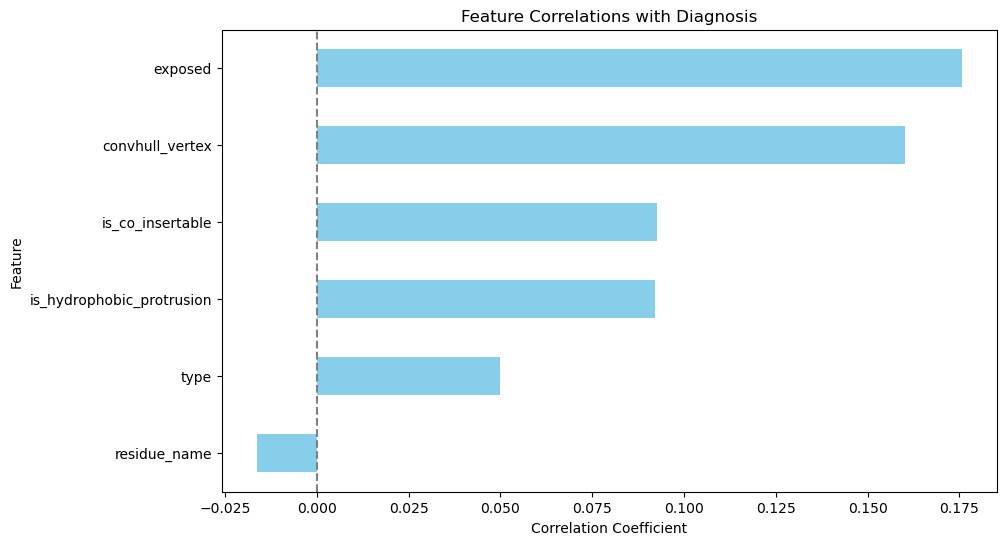

In [17]:
selected_features, correlations=select_features(X, y, threshold=0.1)
                                        
print(selected_features)

# Creates a new dataset that contains only the selected features 
X_selected=X[selected_features]
#print(X_selected)

selected_feature_names = X_selected.columns.tolist()
target = 'IBS'
selected_df = df_new[selected_feature_names + [target]]
print(selected_df)

plt.figure(figsize=(10, 6))
correlations.sort_values().plot(kind='barh', color='skyblue')
plt.title("Feature Correlations with Diagnosis")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.axvline(0, color='grey', linestyle='--')
plt.show()

### Save dataset 

In [16]:
df_new.to_csv("/home/user_stel/AISB/Project/dataset/processed_dataset.csv", index=False)